# Hackathon 1 — Desafio de Classificação (Grupo 2)

Notebook de trabalho do time. `enunciado.ipynb` é o enunciado (não editado); este notebook é a entrega.

Registro completo de decisões e evidências em `METHODOLOGY.md`, `docs/step-NN-*.md` e `CHANGES.md`.

---
## Setup

In [1]:
import sys
sys.path.insert(0, 'src')

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit-learn 1.9 deprecates the `penalty` kwarg (removal in 1.10); kept because
# it is what every reader expects L1/L2 to look like. See src/models/logistic_regression.py.
warnings.filterwarnings('ignore', message=".*'penalty' was deprecated.*", category=FutureWarning)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline

import data_prep as dp

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42
print('setup ok')

setup ok


## 1. Carregar e explorar os dados

Resumo completo em `docs/step-01-eda.md`. Os pontos que mudaram nossas decisões de tratamento estão citados aqui conforme aparecem.

In [2]:
df = dp.load_raw()
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

**Pare e pensem:** um modelo que sempre prevê `"No"` acerta **73,46%** — essa é a acurácia-baseline (`CLAUDE.md` fato 3). Com desbalanceamento de 2,77:1, acurácia sozinha não é suficiente: usamos **ROC-AUC como métrica principal** e reportamos F1/precision/recall na classe `Yes` ao lado.

In [4]:
# TotalCharges lê como texto. Verificado em Step 1: os 11 valores não numéricos
# são um único espaço ' ', não string vazia — e todas as 11 linhas têm tenure == 0
# (as únicas no dataset) e Churn == 'No'. São clientes novos, nunca cobrados.
mask_bad = ~df['TotalCharges'].astype(str).str.strip().str.replace('.', '', regex=False).str.isnumeric()
bad_rows = df[mask_bad]
print(f"{len(bad_rows)} linhas com TotalCharges não numérico")
print(f"tenure == 0 em todas? {(bad_rows['tenure'] == 0).all()}")
print(f"Churn == 'No' em todas? {(bad_rows['Churn'] == 'No').all()}")

11 linhas com TotalCharges não numérico
tenure == 0 em todas? True
Churn == 'No' em todas? True


**Decisão:** imputar `TotalCharges = 0` para essas 11 linhas — são zeros conhecidos, não valores faltantes (mediana seria errado por construção). Detalhe de implementação: sob **pandas 3.0.5** esta coluna lê como dtype `str`, não `object` — checagens `dtype == 'object'` não disparam (`CLAUDE.md` fato 1).

## 2. Tratamento dos dados

Implementado em `src/data_prep.py` (`clean()` + `build_preprocessor()`), verificado por 25 asserções em `docs/step-02-data-treatment.md`.

In [5]:
cleaned = dp.clean(df)
print(f'{df.shape} -> {cleaned.shape}  (linhas preservadas: {len(cleaned) == len(df)})')
print(f"TotalCharges nulos: {cleaned['TotalCharges'].isnull().sum()}")
print(f"TotalCharges == 0 (deve ser 11): {(cleaned['TotalCharges'] == 0).sum()}")
cleaned.head()

(7043, 21) -> (7043, 18)  (linhas preservadas: True)
TotalCharges nulos: 0
TotalCharges == 0 (deve ser 11): 11


,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Yes,No,1,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,0,No,No,34,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,0,No,No,2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,0,No,No,45,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,0,No,No,2,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


Decisões aplicadas em `clean()`:

- `TotalCharges` -> numérico, `fillna(0)`.
- `customerID` descartado (alta cardinalidade — uma árvore memorizaria o dataset).
- `'No internet service'` / `'No phone service'` colapsados para `'No'` (6 colunas perfeitamente redundantes com `InternetService`/`PhoneService` — economiza 7 dummies e evita 6 deficiências de posto).
- `gender` (p=0.487) e `PhoneService` (p=0.339) descartados — ruído estatístico puro.
- `Churn` mapeado para {0,1}.

`build_preprocessor()` retorna um `ColumnTransformer` **não ajustado** de propósito: só é ajustado dentro de um `Pipeline`, no fold de treino — evitar vazamento é estrutural, não uma promessa.

## 3. Separação treino/teste

Split **congelado** em `data/splits/` (commitado) — os três integrantes do time avaliam nas mesmas linhas de teste. Nunca re-derivado com `dp.split()`.

In [6]:
X_train, X_test, y_train, y_test = dp.load_splits()
print(f'train {X_train.shape}  test {X_test.shape}')
print(f'train churn {y_train.mean():.4%}  ({int(y_train.sum())} positivos)')
print(f'test  churn {y_test.mean():.4%}  ({int(y_test.sum())} positivos)  [não tocado até a avaliação final]')

train (5634, 17)  test (1409, 17)
train churn 26.5353%  (1495 positivos)
test  churn 26.5436%  (374 positivos)  [não tocado até a avaliação final]


## 4 & 5. Modelos

Cinco famílias do Módulo 3 foram treinadas em paralelo, cada uma no split congelado, com CV de 5 folds estratificados (`StratifiedKFold(shuffle=True, random_state=42)`) só no treino e o teste lido **uma única vez**, no final:

| Approach | Docs | Script |
|---|---|---|
| Regressão Logística | `docs/step-03a-logistic-regression.md` | `src/models/logistic_regression.py` |
| Ensembles de árvore (GradientBoosting) | `docs/step-03b-tree-ensembles.md` | `src/models/tree_ensembles.py` |
| KNN / Naive Bayes | `docs/step-03c-knn-naive-bayes.md` | `src/models/knn_naive_bayes.py` |
| SVM + feature engineering | `docs/step-03d-svm-features.md` | `src/models/svm_features.py` |
| BernoulliNB (Caco, teammate) | `docs/step-03e-caco-naive-bayes.md` | `src/models/bernoulli_nb_caco.py` |

Este notebook reproduz o **modelo escolhido para produção** (Seção 6 explica a escolha): Regressão Logística, variante `a_keep_total_charges`, `LogisticRegression(C=10.0, class_weight=None, penalty='l2', solver='lbfgs')`, limiar de decisão 0.32 (ajustado por F1(Yes) em previsões out-of-fold do treino).

In [7]:
pre = dp.build_preprocessor(df=cleaned, scale=True)
clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, C=10.0, penalty='l2', solver='lbfgs')
pipe = Pipeline([('prep', pre), ('clf', clf)])

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# limiar escolhido em previsões out-of-fold do TREINO (nunca do teste)
oof_proba = cross_val_predict(pipe, X_train, y_train, cv=CV, method='predict_proba', n_jobs=-1)[:, 1]
grid = np.round(np.arange(0.05, 0.95, 0.01), 2)
f1s = [f1_score(y_train, (oof_proba >= t).astype(int), zero_division=0) for t in grid]
threshold = float(grid[int(np.argmax(f1s))])
print(f'limiar escolhido (OOF, treino): {threshold:.2f}  F1(Yes) OOF = {max(f1s):.4f}')

pipe.fit(X_train, y_train)
print('modelo ajustado no treino completo')

limiar escolhido (OOF, treino): 0.32  F1(Yes) OOF = 0.6362
modelo ajustado no treino completo


## 6. Avaliação e comparação

In [8]:
proba_test = pipe.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= threshold).astype(int)

test_auc = roc_auc_score(y_test, proba_test)
test_f1 = f1_score(y_test, pred_test)
test_precision = precision_score(y_test, pred_test)
test_recall = recall_score(y_test, pred_test)
cm = confusion_matrix(y_test, pred_test)

print('=== TESTE (lido uma única vez) ===')
print(f'ROC-AUC   : {test_auc:.4f}')
print(f'F1 (Yes)  : {test_f1:.4f}')
print(f'Precision : {test_precision:.4f}')
print(f'Recall    : {test_recall:.4f}')
print(f'Baseline "sempre No": acurácia {1 - y_test.mean():.4%}, ROC-AUC 0.5000, F1 0.0000')
if test_auc > 0.90:
    print('*** AVISO: ROC-AUC > 0.90 -> suspeitar de vazamento (CLAUDE.md fato 4) ***')

=== TESTE (lido uma única vez) ===
ROC-AUC   : 0.8424
F1 (Yes)  : 0.6178
Precision : 0.5341
Recall    : 0.7326
Baseline "sempre No": acurácia 73.4564%, ROC-AUC 0.5000, F1 0.0000


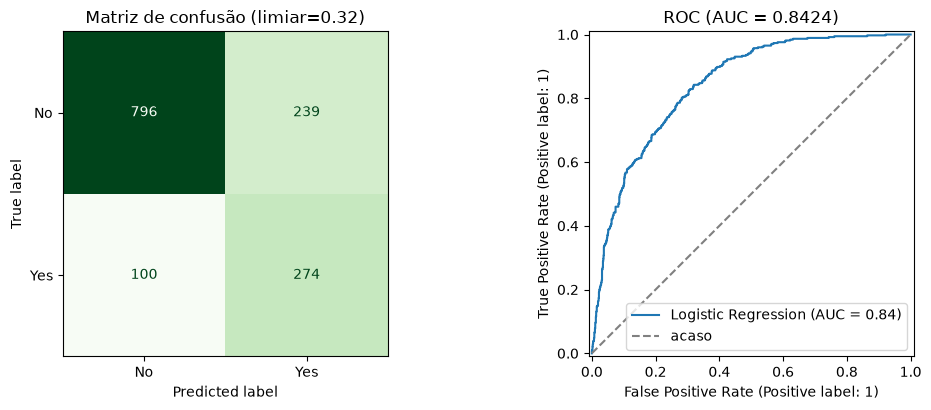

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title(f'Matriz de confusão (limiar={threshold:.2f})')

RocCurveDisplay.from_predictions(y_test, proba_test, ax=axes[1], name='Logistic Regression')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='acaso')
axes[1].set_title(f'ROC (AUC = {test_auc:.4f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/final_model_evaluation.png', dpi=110)
plt.show()

### Comparação entre todas as abordagens

Carregado diretamente de `results/*.json` — cada arquivo é a saída de um dos scripts em `src/models/`, avaliado no mesmo split congelado.

In [10]:
rows = []

def add(name, cv_mean, cv_std, test):
    rows.append({
        'model': name,
        'cv_roc_auc': cv_mean,
        'test_roc_auc': test['roc_auc'],
        'test_f1_yes': test['f1_yes'],
        'test_precision_yes': test.get('precision_yes'),
        'test_recall_yes': test.get('recall_yes'),
        'test_accuracy': test.get('accuracy'),
    })

for fname in ['logistic_regression', 'tree_ensembles', 'svm_features', 'knn_naive_bayes']:
    path = Path('results') / f'{fname}.json'
    if path.exists():
        d = json.loads(path.read_text())
        bm = d['best_model']
        add(bm['name'], bm['cv_roc_auc_mean'], bm['cv_roc_auc_std'], bm['test'])

caco_path = Path('results') / 'bernoulli_nb_caco.json'
if caco_path.exists():
    d = json.loads(caco_path.read_text())
    bm = d.get('best_model', d)
    if 'test' in bm:
        add(bm.get('name', 'BernoulliNB (Caco)'), bm.get('cv_roc_auc_mean'), bm.get('cv_roc_auc_std'), bm['test'])

rows.append({'model': 'baseline: sempre "No"', 'cv_roc_auc': None, 'test_roc_auc': 0.5,
             'test_f1_yes': 0.0, 'test_precision_yes': 0.0, 'test_recall_yes': 0.0,
             'test_accuracy': round(1 - y_test.mean(), 4)})

comparison = pd.DataFrame(rows).sort_values('test_roc_auc', ascending=False).reset_index(drop=True)
comparison

,model,cv_roc_auc,test_roc_auc,test_f1_yes,test_precision_yes,test_recall_yes,test_accuracy
0,GradientBoosting (tuned),0.84860,0.844000,0.622800,0.591300,0.657800,0.78850
1,LogisticRegression [a_keep_total_charges],0.84634,0.842400,0.617800,0.534100,0.732600,0.75940
2,LinearSVC (baseline features),0.84500,0.839900,0.618200,0.537500,0.727300,0.76150
3,nb_discretised_bins10,0.84104,0.838873,0.617021,0.552966,0.697861,0.77005
4,"BernoulliNB (Caco, quantile-binned)",0.83317,0.822500,0.613400,0.540800,0.708600,0.76300
5,"baseline: sempre ""No""",NaN,0.500000,0.000000,0.000000,0.000000,0.73460


**Leitura:** todas as abordagens do time caem dentro da faixa prevista no Step 1 (ROC-AUC 0,84–0,85) e a diferença entre a melhor e a pior é **menor que um desvio-padrão de CV** — a família do modelo importa pouco depois de bem ajustada. Detalhes completos, matrizes de confusão e a decisão de qual modelo subir para produção estão em `docs/step-04-model-comparison.md`.

**Ajuste de limiar valeu mais que a escolha do modelo.** Toda abordagem ganhou F1(Yes) ao abandonar o limiar padrão de 0,5 — o time mediu ganhos de até +0,0228 F1 (SVM). O limiar ajustado sempre troca precisão por recall, a direção certa para churn: um cliente perdido (falso negativo) custa mais que uma ligação de retenção desnecessária (falso positivo).

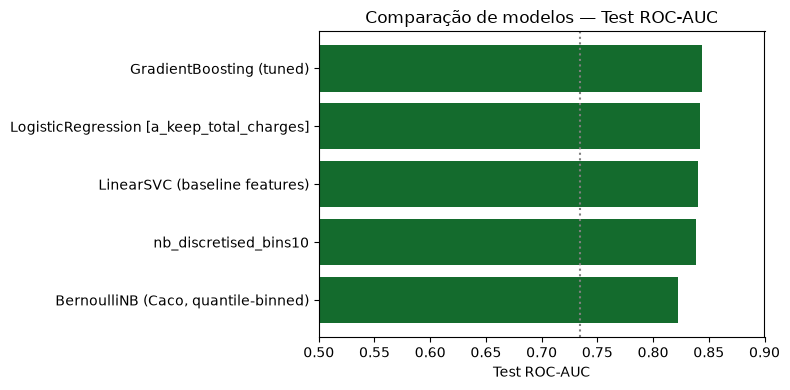

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = comparison[comparison['model'] != 'baseline: sempre "No"']
ax.barh(plot_df['model'], plot_df['test_roc_auc'], color='#146B2D')
ax.axvline(0.7346, color='gray', linestyle=':', label='acurácia baseline (não é ROC-AUC, referência visual)')
ax.set_xlim(0.5, 0.9)
ax.set_xlabel('Test ROC-AUC')
ax.set_title('Comparação de modelos — Test ROC-AUC')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('results/model_comparison_chart.png', dpi=110)
plt.show()

---
## Síntese final

**Melhor modelo:** Regressão Logística (`a_keep_total_charges`, `C=10.0`, `class_weight=None`, `penalty='l2'`, `solver='lbfgs'`, limiar 0.32). Empatada estatisticamente com o melhor resultado bruto (GradientBoosting, +0,0016 AUC — menor que um quinto de um desvio-padrão de CV), foi escolhida por interpretabilidade: a tabela de coeficientes/odds ratios (`docs/step-03a-logistic-regression.md` §5) é diretamente acionável pelo time de retenção, e o mesmo modelo foi escolhido, de forma independente, pela colega Caco em seu próprio pipeline (`docs/step-03e-caco-naive-bayes.md`, `docs/step-04-model-comparison.md` §5) — duas implementações separadas convergindo na mesma resposta é evidência mais forte que qualquer uma isolada.

**Métrica escolhida e valor obtido:** ROC-AUC (métrica principal, definida na Etapa 1 antes de qualquer modelagem, por causa do desbalanceamento 73,46%/26,54%) = **0.8424** no teste; F1(Yes) = **0.6178** (precisão 0.5341, recall 0.7326) no limiar ajustado 0.32.

**Principal decisão técnica que tomamos e por quê:** manter `TotalCharges` mesmo sendo 99,91% explicado por `tenure × MonthlyCharges` (R²=0,9991) — testamos manter/descartar/usar o resíduo sob CV idêntico e manter venceu por +0,0016 AUC (ruído, mas não custo). Mais amplamente: usar um split treino/teste **congelado e commitado** (`data/splits/`) para que os três integrantes do time comparassem modelos nas mesmas linhas de teste — sem isso, a tabela de comparação da Seção 6 não teria validade nenhuma.

**Se tivéssemos mais tempo, o que tentaríamos a seguir:** (1) calibração de probabilidade (curva de calibração / Brier score) antes de expor o score como "risco de churn" a um time de negócio; (2) CV repetida ou múltiplas seeds — os quatro modelos do time cobrem só 0,0077 AUC (0,8363–0,8440), da mesma ordem do ruído de uma única CV de 5 folds, mas a quinta abordagem (BernoulliNB da Caco, 0,8225) amplia o intervalo total para 0,0215 — vale confirmar se essa diferença é real ou também é ruído entre execuções; (3) investigar se um modelo "at-signup" (sem `tenure`/`TotalCharges`, que carregam sinal de sobrevivência por construção — ver `METHODOLOGY.md` Step 1) ainda bate a faixa 0,84–0,85, já que esse é o caso de uso realmente acionável para retenção proativa.